With this notebook, we can run some sample predictions from covid images taken from the internet.

In [1]:
# Use this cell, whenever a change was made to the helper functions
# and the library needs to be reloaded in order to take effect
import prediction
import importlib
importlib.reload(prediction)

2025-04-04 22:44:28.061121: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/markusfuchs/Development/Machine Learning Engineer/Covid-19_detection/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


<module 'prediction' from '/Users/markusfuchs/Development/Machine Learning Engineer/Covid-19_detection/notebooks/prediction.py'>

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

In [3]:
# Scan the models directory for model files
model_dir = os.path.join('..','models')
model_files = os.listdir(model_dir)
print(f"Found {len(model_files)} model files:")
models_2classes = []
models_4classes = []
for model_file in model_files:
    print(f"- {model_file}")
    if '2-classes' in model_file:
        models_2classes.append(model_file)
    else:
        models_4classes.append(model_file)

# insert the saved keras model file name here for the model to load
model_dict_4classes = {file[:20]: os.path.join(model_dir, file) for file in models_4classes}
model_dict_2classes = {file[:20]: os.path.join(model_dir, file) for file in models_2classes}
#    '3a1': '3a1 - model_vgg16_4-classes_learnlong.keras',
#    '3d': '3d - model_efficientnetb1_4-classes.keras',
#    '4-fromscratch_25': '4 - fromscratch_4-classes_25-epochs.keras',
#    '4-fromscratch_50': '4 - fromscratch_4-classes_50-epochs.keras',
#    '4-finetuning_effnet': '4 - finetuning_efficientnetb1_4-classes.keras',
#    '4-finetuning_vgg16': '4 - finetuning_vgg16_4-classes.keras',

from tensorflow import keras
# Load the models
# Note: The models are loaded into memory, so make sure you have enough RAM
models_4 = {model_name: keras.models.load_model(model_path) for model_name, model_path in model_dict_4classes.items()}
models_2 = {model_name: keras.models.load_model(model_path) for model_name, model_path in model_dict_2classes.items()}

class_names_2 = ['Normal', 'COVID']

Found 10 model files:
- 4 - finetuning_vgg16_4-classes.keras
- dense121_2-classes_masked.keras
- 4 - fromscratch_4-classes_25-epochs.keras
- vgg16_augmented_4-classes.keras
- vgg16_4-classes.keras
- 4 - fromscratch_4-classes_50-epochs.keras
- 3a1 - model_vgg16_4-classes_learnlong.keras
- 4 - finetuning_efficientnetb1_4-classes.keras
- 3d - model_efficientnetb1_4-classes.keras
- vgg16_2-classes_masked.keras


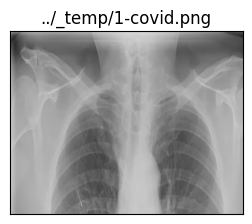

Model input shape is: (None, 224, 224, 3)
Resizing for model 4 - finetuning_vgg16 to input_shape: (224, 224)


I0000 00:00:1743799505.651345 11375887 service.cc:145] XLA service 0x7ff0aeca0860 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1743799505.651390 11375887 service.cc:153]   StreamExecutor device (0): Host, Default Version
2025-04-04 22:45:05.651994: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-04 22:45:05.677892: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1743799506.188460 11375887 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Model input shape is: (None, 256, 256, 1)
Converting image to grayscale for model 4 - fromscratch_4-cl
Resizing for model 4 - fromscratch_4-cl to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_augmented_4-cl to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 954ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_4-classes.kera to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Model input shape is: (None, 224, 224, 3)
Resizing for model 3a1 - model_vgg16_4- to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Model input shape is: (None, 256, 256, 3)
Resizing for model 4 - finetuning_effic to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
Model input shape is: (None, 256, 256, 3)
Resizing for model 3d - model_efficient to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step


,Model_Prediction,COVID,Lung_Opacity,Normal,Viral Pneumonia
4 - finetuning_vgg16,COVID,1.000,0.000,0.000,0.000
4 - fromscratch_4-cl,COVID,0.561,0.035,0.032,0.371
vgg16_augmented_4-cl,Lung_Opacity,0.000,0.714,0.259,0.027
vgg16_4-classes.kera,Viral Pneumonia,0.061,0.000,0.000,0.938
3a1 - model_vgg16_4-,COVID,0.891,0.094,0.013,0.001
4 - finetuning_effic,COVID,1.000,0.000,0.000,0.000
3d - model_efficient,Normal,0.001,0.126,0.873,0.000


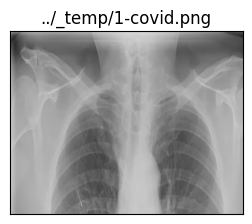

Model input shape is: (None, 224, 224, 3)
Resizing for model dense121_2-classes_m to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_2-classes_mask to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


,Model_Prediction,Normal,COVID
dense121_2-classes_m,COVID,0.276,0.724
vgg16_2-classes_mask,COVID,0.081,0.919


In [4]:
file_path = '../_temp/1-covid.png'
prediction.show_predict_image(file_path, prediction.load_image_from_filepath(file_path), models_4)
prediction.show_predict_image(file_path, prediction.load_image_from_filepath(file_path), models_2, class_names_2)

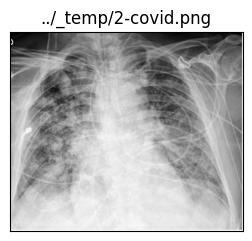

Model input shape is: (None, 224, 224, 3)
Resizing for model 4 - finetuning_vgg16 to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 771ms/step
Model input shape is: (None, 256, 256, 1)
Converting image to grayscale for model 4 - fromscratch_4-cl
Resizing for model 4 - fromscratch_4-cl to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_augmented_4-cl to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 646ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_4-classes.kera to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model 3a1 - model_vgg16_4- to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 809ms/step
Model input shape is: (None, 256, 256, 3)
Resizing for model 4 - finetuning_effic to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Model input shape is: (None, 256, 256, 3)
Resizing for

,Model_Prediction,COVID,Lung_Opacity,Normal,Viral Pneumonia
4 - finetuning_vgg16,COVID,1.000,0.000,0.0,0.0
4 - fromscratch_4-cl,COVID,1.000,0.000,0.0,0.0
vgg16_augmented_4-cl,Lung_Opacity,0.000,1.000,0.0,0.0
vgg16_4-classes.kera,COVID,1.000,0.000,0.0,0.0
3a1 - model_vgg16_4-,COVID,1.000,0.000,0.0,0.0
4 - finetuning_effic,COVID,1.000,0.000,0.0,0.0
3d - model_efficient,COVID,0.731,0.269,0.0,0.0


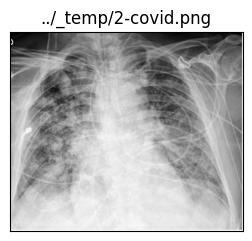

Model input shape is: (None, 224, 224, 3)
Resizing for model dense121_2-classes_m to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_2-classes_mask to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step


,Model_Prediction,Normal,COVID
dense121_2-classes_m,COVID,0.289,0.711
vgg16_2-classes_mask,COVID,0.006,0.994


In [5]:
file_path = '../_temp/2-covid.png'
prediction.show_predict_image(file_path, prediction.load_image_from_filepath(file_path), models_4)
prediction.show_predict_image(file_path, prediction.load_image_from_filepath(file_path), models_2, class_names_2)
# This picture was correctly predicted by all models

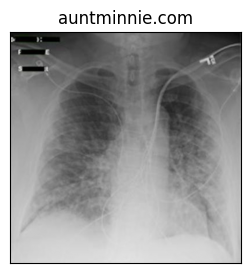

Model input shape is: (None, 224, 224, 3)
Resizing for model 4 - finetuning_vgg16 to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step
Model input shape is: (None, 256, 256, 1)
Converting image to grayscale for model 4 - fromscratch_4-cl
Resizing for model 4 - fromscratch_4-cl to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_augmented_4-cl to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_4-classes.kera to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model 3a1 - model_vgg16_4- to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 554ms/step
Model input shape is: (None, 256, 256, 3)
Resizing for model 4 - finetuning_effic to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Model input shape is: (None, 256, 256, 3)
Resizing for

,Model_Prediction,COVID,Lung_Opacity,Normal,Viral Pneumonia
4 - finetuning_vgg16,Lung_Opacity,0.000,0.986,0.014,0.0
4 - fromscratch_4-cl,COVID,0.998,0.000,0.002,0.0
vgg16_augmented_4-cl,Lung_Opacity,0.004,0.962,0.033,0.0
vgg16_4-classes.kera,COVID,0.999,0.001,0.000,0.0
3a1 - model_vgg16_4-,COVID,0.885,0.114,0.000,0.0
4 - finetuning_effic,COVID,0.999,0.001,0.000,0.0
3d - model_efficient,COVID,0.958,0.040,0.002,0.0


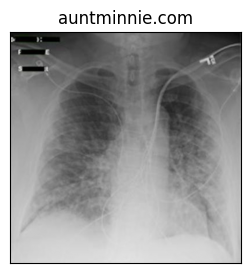

Model input shape is: (None, 224, 224, 3)
Resizing for model dense121_2-classes_m to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_2-classes_mask to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step


,Model_Prediction,Normal,COVID
dense121_2-classes_m,COVID,0.453,0.547
vgg16_2-classes_mask,COVID,0.002,0.998


In [6]:
file_url = 'https://img.auntminnie.com/files/base/smg/all/image/2022/02/am.2022_02_02_00_09_3090_2022_02_03_CXR_covid_19_20220202005447.png?auto=format%2Ccompress&q=70&w=880'
prediction.show_predict_image('auntminnie.com', prediction.load_image_from_url(file_url), models_4)
prediction.show_predict_image('auntminnie.com', prediction.load_image_from_url(file_url), models_2, class_names_2)

# This picture was almost correctly predicted by all models

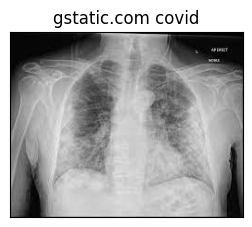

Model input shape is: (None, 224, 224, 3)
Resizing for model 4 - finetuning_vgg16 to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
Model input shape is: (None, 256, 256, 1)
Converting image to grayscale for model 4 - fromscratch_4-cl
Resizing for model 4 - fromscratch_4-cl to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_augmented_4-cl to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_4-classes.kera to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model 3a1 - model_vgg16_4- to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step
Model input shape is: (None, 256, 256, 3)
Resizing for model 4 - finetuning_effic to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Model input shape is: (None, 256, 256, 3)
Resizing for

,Model_Prediction,COVID,Lung_Opacity,Normal,Viral Pneumonia
4 - finetuning_vgg16,Lung_Opacity,0.027,0.825,0.148,0.0
4 - fromscratch_4-cl,Normal,0.000,0.007,0.993,0.0
vgg16_augmented_4-cl,Lung_Opacity,0.044,0.677,0.278,0.0
vgg16_4-classes.kera,COVID,1.000,0.000,0.000,0.0
3a1 - model_vgg16_4-,COVID,0.991,0.009,0.001,0.0
4 - finetuning_effic,COVID,1.000,0.000,0.000,0.0
3d - model_efficient,COVID,0.997,0.003,0.000,0.0


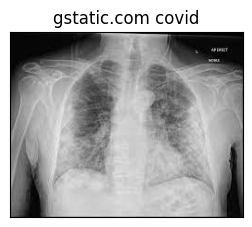

Model input shape is: (None, 224, 224, 3)
Resizing for model dense121_2-classes_m to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_2-classes_mask to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step


,Model_Prediction,Normal,COVID
dense121_2-classes_m,COVID,0.241,0.759
vgg16_2-classes_mask,COVID,0.008,0.992


In [7]:
file_url = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQKe1yUy6RVrg4WbloO-rjTRwPor5mW2zGeItPe1lO4wAyTuY1O0rE99XWl1TCCrcZ1IRU&usqp=CAU'
prediction.show_predict_image('gstatic.com covid', prediction.load_image_from_url(file_url), models_4)
prediction.show_predict_image('gstatic.com covid', prediction.load_image_from_url(file_url), models_2, class_names_2)

# our from scratch model failed on this one

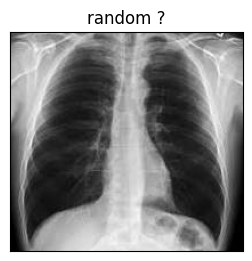

Model input shape is: (None, 224, 224, 3)
Resizing for model 4 - finetuning_vgg16 to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step
Model input shape is: (None, 256, 256, 1)
Converting image to grayscale for model 4 - fromscratch_4-cl
Resizing for model 4 - fromscratch_4-cl to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_augmented_4-cl to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_4-classes.kera to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model 3a1 - model_vgg16_4- to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step
Model input shape is: (None, 256, 256, 3)
Resizing for model 4 - finetuning_effic to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Model input shape is: (None, 256, 256, 3)
Resizing for

,Model_Prediction,COVID,Lung_Opacity,Normal,Viral Pneumonia
4 - finetuning_vgg16,Normal,0.000,0.010,0.990,0.000
4 - fromscratch_4-cl,Viral Pneumonia,0.004,0.074,0.015,0.908
vgg16_augmented_4-cl,Normal,0.000,0.003,0.886,0.110
vgg16_4-classes.kera,COVID,0.550,0.000,0.000,0.450
3a1 - model_vgg16_4-,COVID,1.000,0.000,0.000,0.000
4 - finetuning_effic,COVID,1.000,0.000,0.000,0.000
3d - model_efficient,COVID,0.999,0.000,0.001,0.000


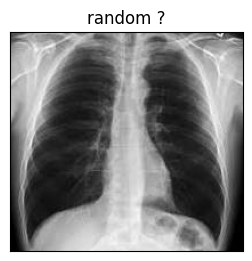

Model input shape is: (None, 224, 224, 3)
Resizing for model dense121_2-classes_m to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_2-classes_mask to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step


,Model_Prediction,Normal,COVID
dense121_2-classes_m,COVID,0.374,0.626
vgg16_2-classes_mask,COVID,0.070,0.930


In [8]:
file_url = 'data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD/2wCEAAkGBwgHBgkIBwgKCgkLDRYPDQwMDRsUFRAWIB0iIiAdHx8kKDQsJCYxJx8fLT0tMTU3Ojo6Iys/RD84QzQ5OjcBCgoKDQwNGg8PGjclHyU3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3N//AABEIAMAAzAMBIgACEQEDEQH/xAAbAAACAwEBAQAAAAAAAAAAAAAFBgMEBwIBAP/EADoQAAIBAwMCBAMHAgUEAwAAAAECAwAEEQUSITFBBhMiUTJhcRQjQoGRobFSwWJy0eHwBxUzkhZDVP/EABQBAQAAAAAAAAAAAAAAAAAAAAD/xAAUEQEAAAAAAAAAAAAAAAAAAAAA/9oADAMBAAIRAxEAPwADpIhCJHNLKE/oiXj9KatOh0pMGKGQuehmfGPyr7SrKK36RIzf1MoP80egRGG1reJie6oAf2oIgrhWIOGxgA9MVA91cIAY5duB2ApjsrFZA8LKHZRlD8vnUA0nc2R5aEHDMe1AuST6iE3tJI6nqSAa8tprqdhF9nhdW6nywMD600yRWEKOjM1zLjByNq0qPJcTjYcCPvGnAH+tAWtlsYW2wTCaXuB8K/rX02kWk5M20Re5HIri104RKJHPlqeSemaF6n4jCO0SEIinA28mguSrBZEiKLecdSMmlXUbrVHvpG2scnCg44FWZNaik5Ls+fcgV5JqNtJH/wCHd/i30EFrf3SemaLn3FHtNmScor+hwc5oNBJE4IICgnlWoxbwKkQc5BPAAoL+sxq8PXhfU2PfFCNKyNXCgYQEEVfvlleBCswJzgZ+lRaDZy/amklkGQOcCgL36xswlkYYA+EUq6p4hS03LDb7h35wKZb+FZogMnbu+LHWljULSCNiRHHgdWbrQVLTxRGr+qBY+55yDTIBZ30SujLtcZ2t0pV8qGZ1VRGQOM7KO2VxHbBYkMPp44ABoJ08PlpH2QMw9mXgj3BNe/8Axi3iPmXA84Hoi9vrRew1VSRFPJhT0yfhqW8up4Wb7PEhzw+8ZEi0ASezt7ePbNNBbR9lXv8ApQt10/ccTzP7eXFnNFrmxgum823KxzHrFIc5+h7/AJ1FDpMiAGQGN3GQNvagFWcMMFx5n2NbxHBUwXURX81YdD8681vTbjWr+JYdPMdvb26W9vDuyI1Ue/fJzzRtbN1PPqHyPFTeS6D0A7j296BB1T/p5dxLxcWSykbvKaXkfnjFKdz4W1KGUo9puI7oykVsNxDdEbZEidR0DJkj6HqKEz27K+NsH0aPkfxQMtnAFHPH70VgjVV3Ac9KqxINnHWr9sN6D3oLFm7KzlDhu1Raq4gCJuLHqBn4j7mrVlAzSDA78mhuoP8AaLx3/DnC0Fe5lkaPkKWYbfSOtcWlgkOZpTjb1P8ATVu1ti8gyM88fWqmu3aRho1YCNPibtmgEeJNTcr5ULbIwOueTSJdyB3L84Pz4q5rWpCQsc7mP6Ut3FzI+etBaVgXC4GKIRxrwroCPkcUtZfJIQk1ct7uWMY8uT69aBo062lYnbsbb0Vm/wBaYdPEiYD7iw6A9KSbDV3jYekuue4p00m5jubYOjYQH1buooC1w0LRKSNpBBAPGeKl0/YiyOo6jg5r6dVltoVIVjnORVmyUJasBEo5AyTQVLvzWxsUsmO1Jeuu0VyYwvPct7/SnTVb2OztpZZH9A4GKzu91P7ZKWCgkHqx7UELS3UY9Nwv/rUf2uceoPn6Gori9CE7ypz2C1S+2BjjaQKAzp+pzeeBI5bno1aboV7FqFt5bn1joMdayezcZDAjOO9OGhylVDoxR16UDBf2G1zgHk8Gi1hdn7PFBcIk8WMFZDyv0Ne2jpqFmSVxIBhx/eqjwmItGecGgutp9qW8y1dtpOFD9QfY1Pe2y2sSoVBdhneO1c6OfOSSN+XUbs+4FdXDs4w3qP8AFAv3kchOTkY7Cg00D+YTyc/Omu4jGC3X+1DWChuB+1AStYWmbYgyTV+2aK3kMZfzGPGE6CqEl2oAt7cgKfjcfiqW3X7xAOx70BJJXabZ8I56UPEe5jgZ5q8pAZj3wa5s0ycjgtwPlQeXUiafZF2PqIwAOpNZ3r1y0iNvbbuPSmvxHeh5mVD6YxgewrOtcvF3HyxuJ6mgE3TBctjPb1ULmuFBPP6V3dPKzEseD7mh7qCSSw/Kgm8+Pr6q7SVT0LiqiKoPLHFTRovdyPyoCVvIT1Iam7wzNGyeX6+evsKQ1ikxuU9+Md6bPC000cqvtGB8WR1oNCuVkt4IfhI55FWbRZH05iRzuzVVZTJHHGRnCA0VhIFjsIIPWgz7xpIy4i3ekn8J4NIz4JZTuYZ7HFaf4htree1aNkBOc59qyzU99vctGW4zxQcSIGPBfH1rwR4PoYj/ADVUNw/IBb9a+WYk8mgKW4kU9C30NNOg32E8uQ5T370nW0/Y/saYNKcN1IYe4oNR8O3KidcNujYbc+31orfW+HGe/WkvRJ/IZDG2ff6VoLbLmyilQ5DLkH+1BQ0v7m9Qj4WyrfTFWzF6tm4N86islHnZPYE18mVZjk4zQV75TEuMdaGkc9Kvy3WZD5qeYnt3/KvkS0mG9LoID+GTgigqRRqowOKtWrfer8jVOWQoATUlhMsjgigKM2M/OrXEFq8nTCHn2qrGu6T5CvdekaGzjjABMmWPyFAi6xOzlhuxH1xjk/OkrUJhuY8qD8+TR/xLfCFWjiOWPV+35Ui305Z2Pqb55oPLm4Q/Dz8zVF5WJ7V4QxOf5rzyycdOaDwtIOhqaGZm4Ydq5EJXq4qzb27bvjXBHFBPBIp2gDGD8OadvCsBu5drqB2BHak1bRDD8RWTHGOcU+eB4pFgaZmO0nkUDLbQut9IR8IGAKKRhjCcngnpQyxOZHPvRCOUgBDjbQCtQhjO7cOgJzWV+JZFfUDsRFC/LrWheL7yS205yh2s74yB2rJrpmuJ3csSSfag4CqzOxCnjtxUW1cDAxXzRfEMYOOtR7sAe2KCzAh3YU/rRexeS3kyvWg0dyVXAPFELG4Ut6Sd3zoHzQroSuA2BJ+xrSNCffp7R4+BgcfWso0hQ7q6sFOMHjqa0zwvOW+7f/ybe/cUBALtkk5+leSHFsfc1LcrtYke2arzn0r86AfcDaOv5UOYZOSf1NX7sjkk4odKw3cAmg71WZYsIep6VLo/ADGgF3e/bb8rGcqpwDR+w4VFWgYrBMkt/V0oJ4xumd1hhPpVcN86OwuIbaVvwxpkH50na1IJLZ5HYLtycnvQIWrEM7B2z/alq7IUEBhiietXuWbZwOx7ml6aQljnnNBy7jPGR9a48zDd68wW+tdLA5HGKCWO4JPwqfrV+zaN2ww2mh6W0oOSBVpIpIvvAgNAxQxpEFWZQyEAqR2+VPmhRq2jr5C7ASfSazi3MnlI7sdwOPrWn+HImXR7dW4LqWJ9uaC3YRPuyUwPrVuZfKKk+/SoomAKgHvVy7BaNSeRQLfiq2E9nIcZGMgD3rL1txA+ZGAJPTOa0vxEXbT5PX07VnyxF3fcDx04oKV48UdtjKGVn6ewoS2wrkqCKkvAwZvM/qOARiqeD0BoJtoPw4Hyq3aRv+Hn51QTKnk1etZVHxen60DT4fvDA+yTLIecmtL8OXO24gkU7k3DB9qyzTSrOu4fmO4p/wDDzNbujnmLvQP16nLAfhND52G0Z7CiJbzrRWU53LwaE3LDJyeMUAHXbjZIqbscZNV7e9gaP1uqkHuaFeIrwvfOc8KMCgv2sj8RoLehSqqZJyx705adMA8dZvo0zYp+0JwZEzztO4/lQNF64g0qUM2O7n2A61l+uaq91KyR8xr8KjoB708eJ7ox6YkGebrcTj+kf7/xWW6jNsXbkIo/UGgFX0KsSWPXsooZJHtycAfXmrdxdgtgbT8z3qlIfM5oIt4zyMn3FdrIvzBqFlYHjpXyofxdKC5HPjqXIojaH7UTGhKcfiFCYgw4AwOxpg0ePyY5Zj+FD8XvjrQXTboAg3A7eOD7Vp9ghj0+FVGRsH6YrIbO5YuHZcLmtasJT9iTIyCgwaDqMkMuFHX3ouQXgAwBQ2FAShNFeCAB2FAq67ZbrWRTncSMYrP4JmjnYO67lbG0n51qGqqJAUP9XH1rMvEUP/btYOxMrKc7vb3oKusvEz7ZZFcOcYBHpoDPEsR+FcHofeptQVi7OcnntVBssPV1FB86qxIBx9DmvUUj4TmuBu6ip4mX8a/+tAX0aZoZQCTtPVW6VpOj3CTQZhPIHKnr/vWa2Ugx6gHWmXSrmW2lWW3fpztPag1vSZd2mbQx+6bjnkA1Q1ZtiyEcd/pmutBuFmtDInCzDGPZhVTXW9BU/EFoEbWOd7+5paluSjkdaZdXfbHj5Ul3kv37UBbRT6F+taJ4eTcrYPUYzWcaIeErSvDYxbSsOrMAP5oKHj67WG4tmLYihgEaAHq2STWZapdNcymQnr29qZ/+oF8bi6iEbZRVKDHuDyaTgO7n8qCqRk5FeBWzjpVlgM8DFRSZXpig6jiwpLEYqZdo+EAj51SMr9+lSRbySei/WgKWkImkQF0UD+qmF/K/7eYo2RmVgDg9frSrbygjAzj+qr9k+IZW6nO4fPHagKW2nTTXEKLHxuUsFPC81ptkhW3jVk5C4zupC8IO7XLMx9LZFaLbBRb5c444oPbdfh4HX+qica89B+tULVQT+dE1wMUAPU4maXGABk0reIdNW+tSCi7lHGeDmnDVzscduaXdQgPJOSGHNBnFwMIYyiq6Nhhih8ixkN92uW7imDxHpz26tdQKQh4b5UpM7A454oPWiIzzwKiHFdid87SOPciu49rdmoPrd3V/QcUyaRdCSQKWCvxjnj8qAiDd09JqeNvJIz2/eg2LwddebNJb4/8ArL4+Y9vyzU+uMWHmf1Jj9P8Agpb/AOn9/wCZeJIxzKikMfdTxmmPXvRDgdMnH0oELXJPT+VJF3KfPam7Wm9J/Okq7b79qBj0Vs7a0rTbj7LpssnTyrR5PzOcf2rMdCPC1oEzhNGuM/8A51U/PgUCLdgy25dzlicqD7d6ATuAc/tRW9ujGSOMk8fSgdwSzls8E9KDkysx5bivd2R1qDqeQalQKo5yaDpULEZNWijYC5G0dqjR40A68/Op2dVI7k9KC5Y2bSRE9Aegq6UjhXYJDtUc4PeqP2oxQqqcd2JGa9inlkLZK4OfwD/SgdvCsce9T+E80/qodFYLwBxST4dIEEOEQj5DpTvaKz2yk+mg6hyGxir6DOD2qgmfM/vRCMYAoBmtAHmhrReapozq+PJyAPzoKs5Un7tSPnQULjS0vLa5hcKd645NZFdW00EskTLiSM4bitqaTkMq4O4Z21m/jZI11FZ1XaZM7j2NApMzMPUc4r4NgZFSSBSeg29eKrNkH5UFr7USADzjvU8MgPOevXNDA1TQyFSPagdPCtydNu47gEeUx2kew71oniA5s1IIJX+COKyixnRkUKTtbClfatHuJjNods7nObNA2O7Jx/agRNaf0n6mk26b75qatbfrSfct981AzaCRgfKni+lC6TCGOPNG8/5QMfzms/0Jzt469qbPFM3k6FbqvUP5IP8AhAzQIl/MWnY9eTgewqqMseTU84DSM3Y1AzY4oOyABUecV6Hrk+o0HhbjPU54q1CTEMsMsen+GoY0CkM3I7VMg3Nk/lQWWLGJcEcjkVYiIjHTLe1cwIoUFlHT3rsHc+CwDew5oH7wvE8sUTJwrEVokESm3UKcYFKnhiyWHT7ZZDhgoJHcGmvawjUR4/WgiAwSM9KvxgnFU07gj1GiEIO1Tigo6yuLVj86AqvY/wAUya6o8gLnGTQJHTkZHHUUFV5MRyBRnaMjms+8cnfajKplW+IDmtDlEeW528dqzvxcjGGdsAgtkUCQTkYyQB3rkuVbDV0yhhgZBrjBPJ5I60EigMK9wVHHWuFO2pQ240FrTbjZMA5wrHB+XzrULNyfD8KMfVCGjYfvWTIjBxjoTxWj+H7n7RocnOcRYJ+a9P2xQKmsNyfpmlSc5lamfW2wW98UpTON5oGLw4w82PPTcP5pm8WktpNmPxedJn8wv+9J+hyepQDinDXT5ulxyD+rePzAoE6bAXHtVJ87vlVm4OXIHTvUBGaDgGpENcIju4RFLMegAzR/TvCmqXWCYxGhHLOen5UAgcgVZhTLAdTngCnKw8CplGnlMn7Ux6f4btLNc+Uityc9TQZxBpl5dMm2MgZ9qb/D3hmON0u7zLOpyqEfvTVDYwxxtgZKnOSKsQoORjigksFbzFycDPNHxJsjwPUOxoVZoQ+e1GiMRhSvOM0FeJwWPpopE6pCCR2ofAQSQVorAEKgMOKBT8WX4QxqDyQSaU59W2A4/WnPxRao9yCEB2r0NLU+mQSqF2YPy6UAD/uku4uWyueRmqOpst9E6r3BwP7UauvDM7HNt6jjoKAXVnf6eQJ7SVASedpI/WgTZIyW9iOKjJwQfbrRW9iVmaROCScq3BoZNHjdighZsVyHINctxwetfKuaAhAdw57/ALU4+EXKaXdA9BMqH6bTSVbNhgpp10aMxaTIenmSg/oKBZ15sOw9uKVpOXNMWvSbpXYdGJNLjHJNAU0Z8SKPnTzdHzNARuysf0A4/ms90t9s4Hua0AHzvDVx/hjLfx/qKBIdsOc55q1p1jLfTbIl9OfirmGze8uVijGSf4rTvCmgpaQCV16jge1BB4b8LQWqrJIo3d2I60z+WBlUAC/IdatEAAADAr1I6DyGLywCB6u1TLAM54I713HHzVyKLPFBU+z7sqQfY18LfZ2oosWOKilioOdPRPOC8HHOKLkI3Xr2odYQYYmiKQE+rpQRx26hi2avRKqKDmuAFCkM2TivApdQewoBeuhTdbieCKGvagRNIgAOMg470U1SPfKo9qpTRuB6D9R8qBaudQkWZYogf8+etWIrxkQCf1pnlG5q/JpcUuX24bOetVJNMLyA4O0dRQR3ejWVx96sKFX9xSrqvhnSZXeNIykg7xnaD/rTXqs4sbby4jnC55+dLcGpK8i/aQ279aBL1fwpcWn3lv8AfJ7HrS+VMbMjja69RW2xfZr+38tOJB0+lI/jDQAoMyJtkXkn3oEyPO4Y654rQDiLQ1K9Gwy4+aikG3BEmX4INPWq5t9GtoG+IQxhvrtBNAh61J96y0Gohqzbpj9aoGgmtW2TVpHhwrPYSwnkOrLj6r/sKzOM4cGnvwlcnhQaC34S0wvO7SAB2OPoB/w1pNugihVV6LxS/o9oYJTLjCNyKPBycAHrzQTLy1W0XJFV4UxzmiFvHk9KCSKHdjIq5HH0r5EwKnRc9KDwJXJj3NsQdasrGScAc1JHEI855Y9aDmK1VOCcn3qeTOxgOnY1zuIbJrrzSwKnAoKTBgcnpVyDmMccd68YHGRz+VfCXA2jp9KCJoxJnzByDwfaoZbV9nG1h9Oanbk8GvBuHfigqJbRqVytSeVGqsQo6VaIVl9jVeVGVSACR70CP4osnILoW9RLYx29qVXR4QTKpI7cdK029s/PAjd8D+KX9Z0KRbYsNpU9TmgB6BKsUiyuCeDjJo3q1oup2JXaAxHFU7PT7aKACaZVYZP0omJF8lUU8Y4PvQZZcaM0fiFbZ0+6Zgzcdvar3iybapGR0z/z/nemrUrDdfJdnAULkn50geLrncznPU8CgTLx98xNQV053MT865oP/9k='
prediction.show_predict_image('random ?', prediction.load_image_from_url(file_url), models_4)
prediction.show_predict_image('random ?', prediction.load_image_from_url(file_url), models_2, class_names_2)


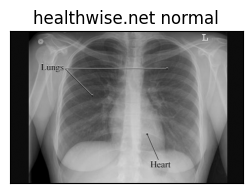

Model input shape is: (None, 224, 224, 3)
Resizing for model 4 - finetuning_vgg16 to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step
Model input shape is: (None, 256, 256, 1)
Converting image to grayscale for model 4 - fromscratch_4-cl
Resizing for model 4 - fromscratch_4-cl to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_augmented_4-cl to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_4-classes.kera to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model 3a1 - model_vgg16_4- to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step
Model input shape is: (None, 256, 256, 3)
Resizing for model 4 - finetuning_effic to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
Model input shape is: (None, 256, 256, 3)
Resizing 

,Model_Prediction,COVID,Lung_Opacity,Normal,Viral Pneumonia
4 - finetuning_vgg16,Normal,0.000,0.100,0.900,0.000
4 - fromscratch_4-cl,COVID,1.000,0.000,0.000,0.000
vgg16_augmented_4-cl,Lung_Opacity,0.000,0.998,0.002,0.000
vgg16_4-classes.kera,COVID,0.769,0.021,0.018,0.192
3a1 - model_vgg16_4-,COVID,1.000,0.000,0.000,0.000
4 - finetuning_effic,Normal,0.000,0.060,0.939,0.000
3d - model_efficient,Lung_Opacity,0.003,0.821,0.177,0.000


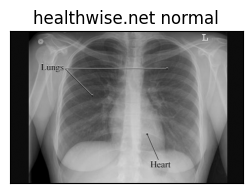

Model input shape is: (None, 224, 224, 3)
Resizing for model dense121_2-classes_m to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_2-classes_mask to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step


,Model_Prediction,Normal,COVID
dense121_2-classes_m,COVID,0.300,0.700
vgg16_2-classes_mask,COVID,0.129,0.871


In [9]:
file_url = 'https://content.ca.healthwise.net/resources/14.1/en-ca/media/medical/hw/h9991297_001.jpg'
prediction.show_predict_image('healthwise.net normal', prediction.load_image_from_url(file_url), models_4)
prediction.show_predict_image('healthwise.net normal', prediction.load_image_from_url(file_url), models_2, class_names_2)

# This image was wrong predicted by all models except for the finetuned efficientnet

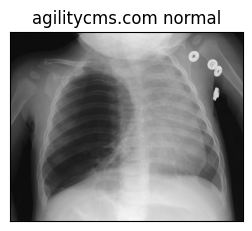

Model input shape is: (None, 224, 224, 3)
Resizing for model 4 - finetuning_vgg16 to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
Model input shape is: (None, 256, 256, 1)
Converting image to grayscale for model 4 - fromscratch_4-cl
Resizing for model 4 - fromscratch_4-cl to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_augmented_4-cl to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_4-classes.kera to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model 3a1 - model_vgg16_4- to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step
Model input shape is: (None, 256, 256, 3)
Resizing for model 4 - finetuning_effic to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Model input shape is: (None, 256, 256, 3)
Resizing for

,Model_Prediction,COVID,Lung_Opacity,Normal,Viral Pneumonia
4 - finetuning_vgg16,Viral Pneumonia,0.001,0.075,0.397,0.527
4 - fromscratch_4-cl,Normal,0.000,0.000,1.000,0.000
vgg16_augmented_4-cl,Lung_Opacity,0.000,0.727,0.197,0.076
vgg16_4-classes.kera,Viral Pneumonia,0.006,0.000,0.001,0.993
3a1 - model_vgg16_4-,COVID,0.417,0.001,0.227,0.355
4 - finetuning_effic,COVID,0.646,0.004,0.038,0.313
3d - model_efficient,Viral Pneumonia,0.000,0.000,0.001,0.999


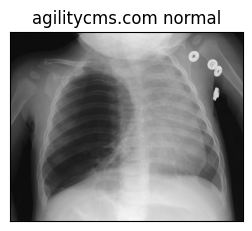

Model input shape is: (None, 224, 224, 3)
Resizing for model dense121_2-classes_m to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_2-classes_mask to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step


,Model_Prediction,Normal,COVID
dense121_2-classes_m,COVID,0.451,0.549
vgg16_2-classes_mask,COVID,0.184,0.816


In [10]:
file_url = 'https://cdn.agilitycms.com/applied-radiology/MediaGroupings/4045/Sood_figure01a.jpg'
prediction.show_predict_image('agilitycms.com normal', prediction.load_image_from_url(file_url), models_4)
prediction.show_predict_image('agilitycms.com normal', prediction.load_image_from_url(file_url), models_2, class_names_2)

# the models randomly predict on this child xray image

(612, 1536, 3)


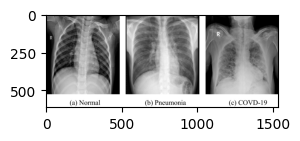

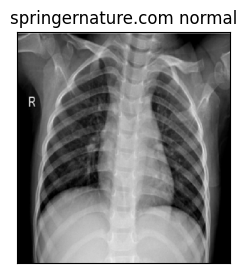

Model input shape is: (None, 224, 224, 3)
Resizing for model 4 - finetuning_vgg16 to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step
Model input shape is: (None, 256, 256, 1)
Converting image to grayscale for model 4 - fromscratch_4-cl
Resizing for model 4 - fromscratch_4-cl to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_augmented_4-cl to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_4-classes.kera to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model 3a1 - model_vgg16_4- to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step
Model input shape is: (None, 256, 256, 3)
Resizing for model 4 - finetuning_effic to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Model input shape is: (None, 256, 256, 3)
Resizing for

,Model_Prediction,COVID,Lung_Opacity,Normal,Viral Pneumonia
4 - finetuning_vgg16,Normal,0.000,0.000,1.000,0.000
4 - fromscratch_4-cl,Normal,0.000,0.000,1.000,0.000
vgg16_augmented_4-cl,Viral Pneumonia,0.000,0.000,0.009,0.991
vgg16_4-classes.kera,Viral Pneumonia,0.000,0.000,0.011,0.989
3a1 - model_vgg16_4-,Normal,0.000,0.000,0.999,0.001
4 - finetuning_effic,Normal,0.144,0.004,0.852,0.000
3d - model_efficient,Normal,0.000,0.000,0.729,0.271


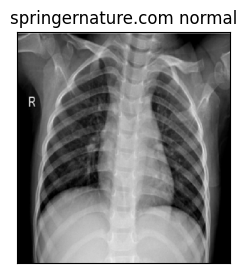

Model input shape is: (None, 224, 224, 3)
Resizing for model dense121_2-classes_m to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_2-classes_mask to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


,Model_Prediction,Normal,COVID
dense121_2-classes_m,COVID,0.352,0.648
vgg16_2-classes_mask,COVID,0.146,0.854


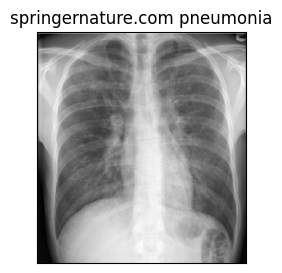

Model input shape is: (None, 224, 224, 3)
Resizing for model 4 - finetuning_vgg16 to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step
Model input shape is: (None, 256, 256, 1)
Converting image to grayscale for model 4 - fromscratch_4-cl
Resizing for model 4 - fromscratch_4-cl to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_augmented_4-cl to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_4-classes.kera to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model 3a1 - model_vgg16_4- to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 613ms/step
Model input shape is: (None, 256, 256, 3)
Resizing for model 4 - finetuning_effic to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Model input shape is: (None, 256, 256, 3)
Resizing for

,Model_Prediction,COVID,Lung_Opacity,Normal,Viral Pneumonia
4 - finetuning_vgg16,COVID,0.992,0.001,0.004,0.004
4 - fromscratch_4-cl,COVID,0.635,0.002,0.080,0.283
vgg16_augmented_4-cl,Normal,0.000,0.135,0.686,0.179
vgg16_4-classes.kera,Viral Pneumonia,0.073,0.000,0.001,0.927
3a1 - model_vgg16_4-,COVID,0.972,0.013,0.014,0.000
4 - finetuning_effic,COVID,0.719,0.030,0.043,0.208
3d - model_efficient,COVID,0.513,0.140,0.344,0.003


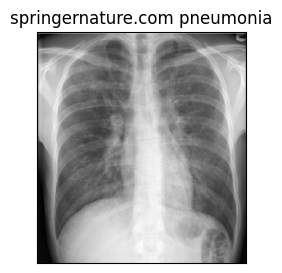

Model input shape is: (None, 224, 224, 3)
Resizing for model dense121_2-classes_m to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_2-classes_mask to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step


,Model_Prediction,Normal,COVID
dense121_2-classes_m,COVID,0.376,0.624
vgg16_2-classes_mask,COVID,0.036,0.964


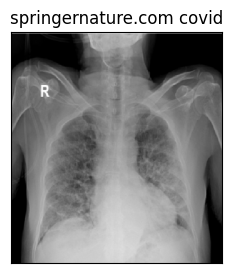

Model input shape is: (None, 224, 224, 3)
Resizing for model 4 - finetuning_vgg16 to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
Model input shape is: (None, 256, 256, 1)
Converting image to grayscale for model 4 - fromscratch_4-cl
Resizing for model 4 - fromscratch_4-cl to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_augmented_4-cl to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_4-classes.kera to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 510ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model 3a1 - model_vgg16_4- to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step
Model input shape is: (None, 256, 256, 3)
Resizing for model 4 - finetuning_effic to input_shape: (256, 256)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Model input shape is: (None, 256, 256, 3)
Resizing for

,Model_Prediction,COVID,Lung_Opacity,Normal,Viral Pneumonia
4 - finetuning_vgg16,Lung_Opacity,0.105,0.865,0.030,0.001
4 - fromscratch_4-cl,COVID,1.000,0.000,0.000,0.000
vgg16_augmented_4-cl,Lung_Opacity,0.063,0.719,0.218,0.000
vgg16_4-classes.kera,COVID,1.000,0.000,0.000,0.000
3a1 - model_vgg16_4-,COVID,1.000,0.000,0.000,0.000
4 - finetuning_effic,COVID,1.000,0.000,0.000,0.000
3d - model_efficient,COVID,0.945,0.053,0.001,0.000


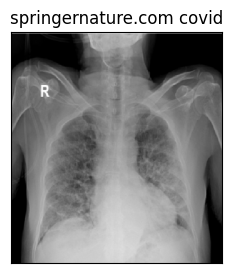

Model input shape is: (None, 224, 224, 3)
Resizing for model dense121_2-classes_m to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
Model input shape is: (None, 224, 224, 3)
Resizing for model vgg16_2-classes_mask to input_shape: (224, 224)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step


,Model_Prediction,Normal,COVID
dense121_2-classes_m,Normal,0.539,0.461
vgg16_2-classes_mask,COVID,0.002,0.998


In [11]:
norm_pneu_covid_url='https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41598-022-27266-9/MediaObjects/41598_2022_27266_Fig1_HTML.png'

img_norm_pneu_covid = prediction.load_image_from_url(norm_pneu_covid_url)
print(img_norm_pneu_covid.shape)
plt.figure(figsize=(3,3))
plt.imshow(img_norm_pneu_covid/255)
plt.show()

img_normal = img_norm_pneu_covid[:520,:480,:]
img_pneumonia = img_norm_pneu_covid[:520,530:1000,:]
img_covid = img_norm_pneu_covid[:520:,1060:,:]

prediction.show_predict_image('springernature.com normal', img_normal, models_4)
prediction.show_predict_image('springernature.com normal', img_normal, models_2, class_names_2)
prediction.show_predict_image('springernature.com pneumonia', img_pneumonia, models_4)
prediction.show_predict_image('springernature.com pneumonia', img_pneumonia, models_2, class_names_2)
prediction.show_predict_image('springernature.com covid', img_covid, models_4)
prediction.show_predict_image('springernature.com covid', img_covid, models_2, class_names_2)
